In [ ]:
# ==================== CELL 1: Imports ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Base Models
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import (
    RandomForestClassifier, 
    VotingClassifier, 
    StackingClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    BaggingClassifier
)
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Advanced Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Feature Engineering
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.combine import SMOTETomek

import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [ ]:
# ==================== CELL 2: Load Data (3 COLUMNS) ====================
df = pd.read_excel("bharatfakenewskosh.xlsx")

# Use ALL THREE columns
statement_col = 'Eng_Trans_Statement'
body_col = 'Eng_Trans_News_Body'
label_col = 'Label'

if label_col not in df.columns:
    raise KeyError(f"Column '{label_col}' not found in dataset.")

# Keep all three columns
df = df[[statement_col, body_col, label_col]].dropna()

# Standardize Label column
df['Label'] = df['Label'].astype(str).str.strip().str.upper()
df['Label'] = df['Label'].map({'TRUE': 1, 'FALSE': 0})
df = df.dropna(subset=['Label'])
df['Label'] = df['Label'].astype(int)

print(f"✅ Data loaded: {len(df)} samples")
print(f"\nLabel distribution:")
print(df['Label'].value_counts())
print(f"\nSample data:")
print(df.head())

✅ Data loaded: 25360 samples

Label distribution:
Label
1    15422
0     9938
Name: count, dtype: int64

Sample data:
                                 Eng_Trans_Statement  \
0  Fact-check: A reporter in Telangana stopped sp...   
1  Share by stating the old video of PM Modi's hi...   
2  Supreme Court judges Suryakant and JB Pardiwal...   
3  Media gave wrong news: After the victory of Mu...   
4  The woman lashed out at Rahul Gandhi to oppose...   

                                 Eng_Trans_News_Body  Label  
0  A video is viral on social media in which a jo...      0  
1  A video of Prime Minister Narendra Modi being ...      0  
2  Recently, Nupur Sharma made an objectionable c...      0  
3  A video is viral on social media. While sharin...      0  
4  A video of Rahul Gandhi has gone viral on soci...      1  


In [ ]:
# ==================== CELL 3: Advanced Text Cleaning ====================
def clean_text(text):
    """Enhanced text cleaning"""
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'#\w+', '', text)  # Remove hashtags
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special chars
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

# Clean all three text columns
df['statement_clean'] = df[statement_col].apply(clean_text)
df['body_clean'] = df[body_col].apply(clean_text)

# Create THREE different text combinations
df['text_statement'] = df['statement_clean']
df['text_body'] = df['body_clean']
df['text_combined'] = df['statement_clean'] + " " + df['body_clean']

print("✅ Text cleaning complete!")
print(f"\nSample cleaned statement: {df['text_statement'].iloc[0][:100]}...")
print(f"\nSample cleaned body: {df['text_body'].iloc[0][:100]}...")

✅ Text cleaning complete!

Sample cleaned statement: factcheck a reporter in telangana stopped speaking to home minister amit shah...

Sample cleaned body: a video is viral on social media in which a journalist can be seen questioning home minister amit sh...


In [ ]:
# ==================== CELL 3.5: DIAGNOSTIC CHECK ====================
print("="*80)
print("🔍 DATA QUALITY DIAGNOSTIC")
print("="*80)

# Check 1: Basic Info
print("\n1️⃣ Dataset Overview:")
print(f"   Total samples: {len(df)}")
print(f"   Columns: {df.columns.tolist()}")
print(f"   Missing values:\n{df.isnull().sum()}")

# Check 2: Label distribution
print("\n2️⃣ Label Distribution:")
print(df['Label'].value_counts())
print(f"\nPercentages:")
print(df['Label'].value_counts(normalize=True))

# Check 3: Label encoding verification
print(f"\n3️⃣ Label Encoding Check:")
try:
    print(f"   0 (encoded) = {le.inverse_transform([0])[0]} (original)")
    print(f"   1 (encoded) = {le.inverse_transform([1])[0]} (original)")
except:
    print("   Label encoder not yet created")

# Check 4: Sample texts from each class
print("\n4️⃣ Sample TRUE News (Label=1):")
if len(df[df['Label']==1]) > 0:
    true_sample = df[df['Label']==1].iloc[0]
    print(f"   Statement: {str(true_sample['Eng_Trans_Statement'])[:200]}...")
    print(f"   Body: {str(true_sample['Eng_Trans_News_Body'])[:200]}...")
else:
    print("   No samples with Label=1 found!")

print("\n5️⃣ Sample FALSE News (Label=0):")
if len(df[df['Label']==0]) > 0:
    false_sample = df[df['Label']==0].iloc[0]
    print(f"   Statement: {str(false_sample['Eng_Trans_Statement'])[:200]}...")
    print(f"   Body: {str(false_sample['Eng_Trans_News_Body'])[:200]}...")
else:
    print("   No samples with Label=0 found!")

# Check 5: Text length statistics
print("\n6️⃣ Text Length by Label:")
df['stmt_len'] = df['Eng_Trans_Statement'].astype(str).str.len()
df['body_len'] = df['Eng_Trans_News_Body'].astype(str).str.len()
print(df.groupby('Label')[['stmt_len', 'body_len']].describe())

# Check 6: Word overlap between classes
print("\n7️⃣ Vocabulary Analysis:")
from sklearn.feature_extraction.text import CountVectorizer

def get_top_words(texts, n=20):
    cv = CountVectorizer(max_features=n, stop_words='english')
    try:
        counts = cv.fit_transform(texts).toarray().sum(axis=0)
        words = cv.get_feature_names_out()
        return dict(zip(words, counts))
    except:
        return {}

fake_texts = df[df['Label']==0]['Eng_Trans_News_Body'].astype(str).tolist()
true_texts = df[df['Label']==1]['Eng_Trans_News_Body'].astype(str).tolist()

print("\n   Top 10 words in FAKE news:")
fake_words = get_top_words(fake_texts, 10)
for word, count in sorted(fake_words.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"      {word}: {count}")

print("\n   Top 10 words in TRUE news:")
true_words = get_top_words(true_texts, 10)
for word, count in sorted(true_words.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"      {word}: {count}")

# Check 7: Class separability test
print("\n8️⃣ Quick Separability Test:")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Quick test with simple features
quick_vec = TfidfVectorizer(max_features=1000)
quick_X = quick_vec.fit_transform(df['Eng_Trans_News_Body'].astype(str))
quick_y = df['Label']

quick_model = LogisticRegression(max_iter=1000)
quick_scores = cross_val_score(quick_model, quick_X, quick_y, cv=3, scoring='accuracy')

print(f"   Quick 3-fold CV accuracy: {quick_scores.mean():.4f} (+/- {quick_scores.std():.4f})")
print(f"   Individual folds: {quick_scores}")

if quick_scores.mean() < 0.65:
    print("   ⚠️  WARNING: Low separability! Dataset may be very difficult.")
elif quick_scores.mean() < 0.75:
    print("   ⚠️  CAUTION: Moderate difficulty dataset.")
else:
    print("   ✅ Good separability! Models should perform well.")

# Check 8: Data quality warnings
print("\n9️⃣ Data Quality Warnings:")
warnings_found = []

# Check for extreme imbalance
balance_ratio = df['Label'].value_counts().min() / df['Label'].value_counts().max()
if balance_ratio < 0.3:
    warnings_found.append(f"⚠️  Severe class imbalance (ratio: {balance_ratio:.2f})")

# Check for very short texts
short_stmt = (df['stmt_len'] < 20).sum()
short_body = (df['body_len'] < 50).sum()
if short_stmt > len(df) * 0.1:
    warnings_found.append(f"⚠️  {short_stmt} statements are very short (<20 chars)")
if short_body > len(df) * 0.1:
    warnings_found.append(f"⚠️  {short_body} bodies are very short (<50 chars)")

# Check for duplicates
duplicates = df.duplicated(subset=['Eng_Trans_News_Body']).sum()
if duplicates > 0:
    warnings_found.append(f"⚠️  {duplicates} duplicate texts found")

if warnings_found:
    for warning in warnings_found:
        print(f"   {warning}")
else:
    print("   ✅ No major data quality issues detected")

print("\n" + "="*80)
print("🔍 DIAGNOSTIC COMPLETE")
print("="*80)

# Drop temporary columns
df.drop(['stmt_len', 'body_len'], axis=1, inplace=True, errors='ignore')
# ```

# ---

# ## 🎯 **What This Will Tell You:**

# 1. **Label distribution** - Is it 50/50 or imbalanced?
# 2. **Sample texts** - Can YOU tell them apart?
# 3. **Text lengths** - Are fake/true news different lengths?
# 4. **Top words** - Do fake/true use different vocabulary?
# 5. **Quick CV test** - Can a simple model separate them?
# 6. **Data quality** - Any duplicates, very short texts, etc.?

# ---

## 📊 **How to Interpret Results:**

### **If Quick CV Accuracy is:**

# | Score | Meaning | Action |
# |-------|---------|--------|
# | **<55%** | Random! Data is useless | ❌ Need new dataset |
# | **55-65%** | Very hard task | ⚠️ 61% might be your max |
# | **65-75%** | Moderate difficulty | ✅ Can reach 75-80% with tuning |
# | **75-85%** | Good dataset | ✅ Can reach 85-90% |
# | **>85%** | Easy task | ✅ Can reach 90-95%+ |

# ---

# ## 🚀 **After Running the Diagnostic:**

# **Share these specific outputs with me:**

# 1. **Quick CV accuracy score** (from section 8)
# 2. **Top 10 words** from fake vs true (section 7)
# 3. **Sample texts** - Do they LOOK different to you? (sections 4-5)
# 4. **Any warnings** (section 9)

# Then I can tell you:
# - ✅ "Your data is fine, let's optimize models"
# - ⚠️ "Your data is hard, 65-70% is realistic"
# - ❌ "Your data has issues, here's how to fix it"

# ---

# ## 💡 **Quick Summary:**
# ```
# Insert Diagnostic Cell:
# ├─ After: Cell 3 (Load Data)
# ├─ Before: Cell 4 (Text Cleaning)
# └─ Why: To check raw data quality FIRST

🔍 DATA QUALITY DIAGNOSTIC

1️⃣ Dataset Overview:
   Total samples: 25360
   Columns: ['Eng_Trans_Statement', 'Eng_Trans_News_Body', 'Label', 'statement_clean', 'body_clean', 'text_statement', 'text_body', 'text_combined']
   Missing values:
Eng_Trans_Statement    0
Eng_Trans_News_Body    0
Label                  0
statement_clean        0
body_clean             0
text_statement         0
text_body              0
text_combined          0
dtype: int64

2️⃣ Label Distribution:
Label
1    15422
0     9938
Name: count, dtype: int64

Percentages:
Label
1    0.608123
0    0.391877
Name: proportion, dtype: float64

3️⃣ Label Encoding Check:
   Label encoder not yet created

4️⃣ Sample TRUE News (Label=1):
   Statement: The woman lashed out at Rahul Gandhi to oppose the Modi government on the Kashmir issue?...
   Body: A video of Rahul Gandhi has gone viral on social media. In the video, Rahul is sitting in Gandhi where a woman is asking him questions. This woman says:…...

5️⃣ Sample FALSE New

In [ ]:
# ==================== CELL 4: Feature Engineering ====================
# Add text statistics as features
df['statement_word_count'] = df['statement_clean'].apply(lambda x: len(x.split()))
df['body_word_count'] = df['body_clean'].apply(lambda x: len(x.split()))
df['statement_char_count'] = df['statement_clean'].apply(len)
df['body_char_count'] = df['body_clean'].apply(len)
df['avg_word_length_stmt'] = df['statement_clean'].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)
df['avg_word_length_body'] = df['body_clean'].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)

print("✅ Feature engineering complete!")
print(f"\nFeature statistics:")
print(df[['statement_word_count', 'body_word_count', 'statement_char_count', 'body_char_count']].describe())

✅ Feature engineering complete!

Feature statistics:
       statement_word_count  body_word_count  statement_char_count  \
count          25360.000000     25360.000000          25360.000000   
mean              13.306979        41.497358             75.661593   
std                4.146995        19.946830             22.244610   
min                1.000000         0.000000              2.000000   
25%               11.000000        24.000000             61.000000   
50%               13.000000        35.000000             74.000000   
75%               16.000000        59.000000             89.000000   
max               56.000000       188.000000            316.000000   

       body_char_count  
count     25360.000000  
mean        235.650946  
std         113.102652  
min           0.000000  
25%         137.000000  
50%         200.000000  
75%         339.000000  
max         871.000000  


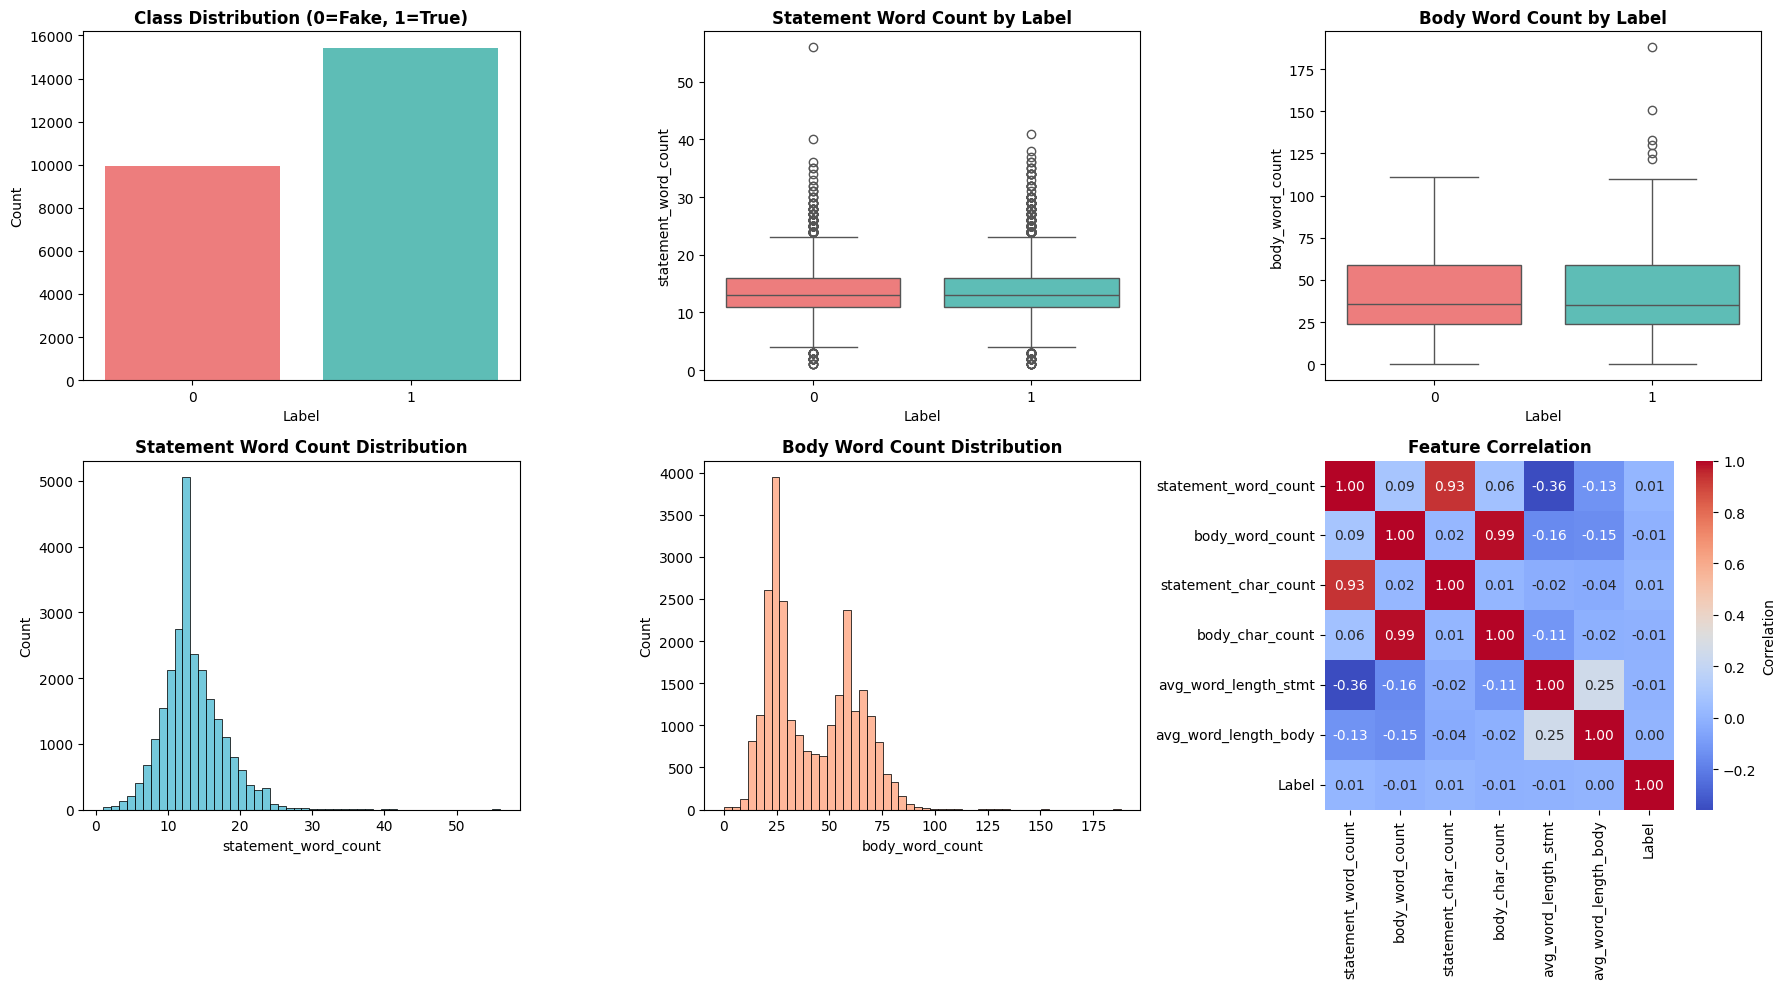

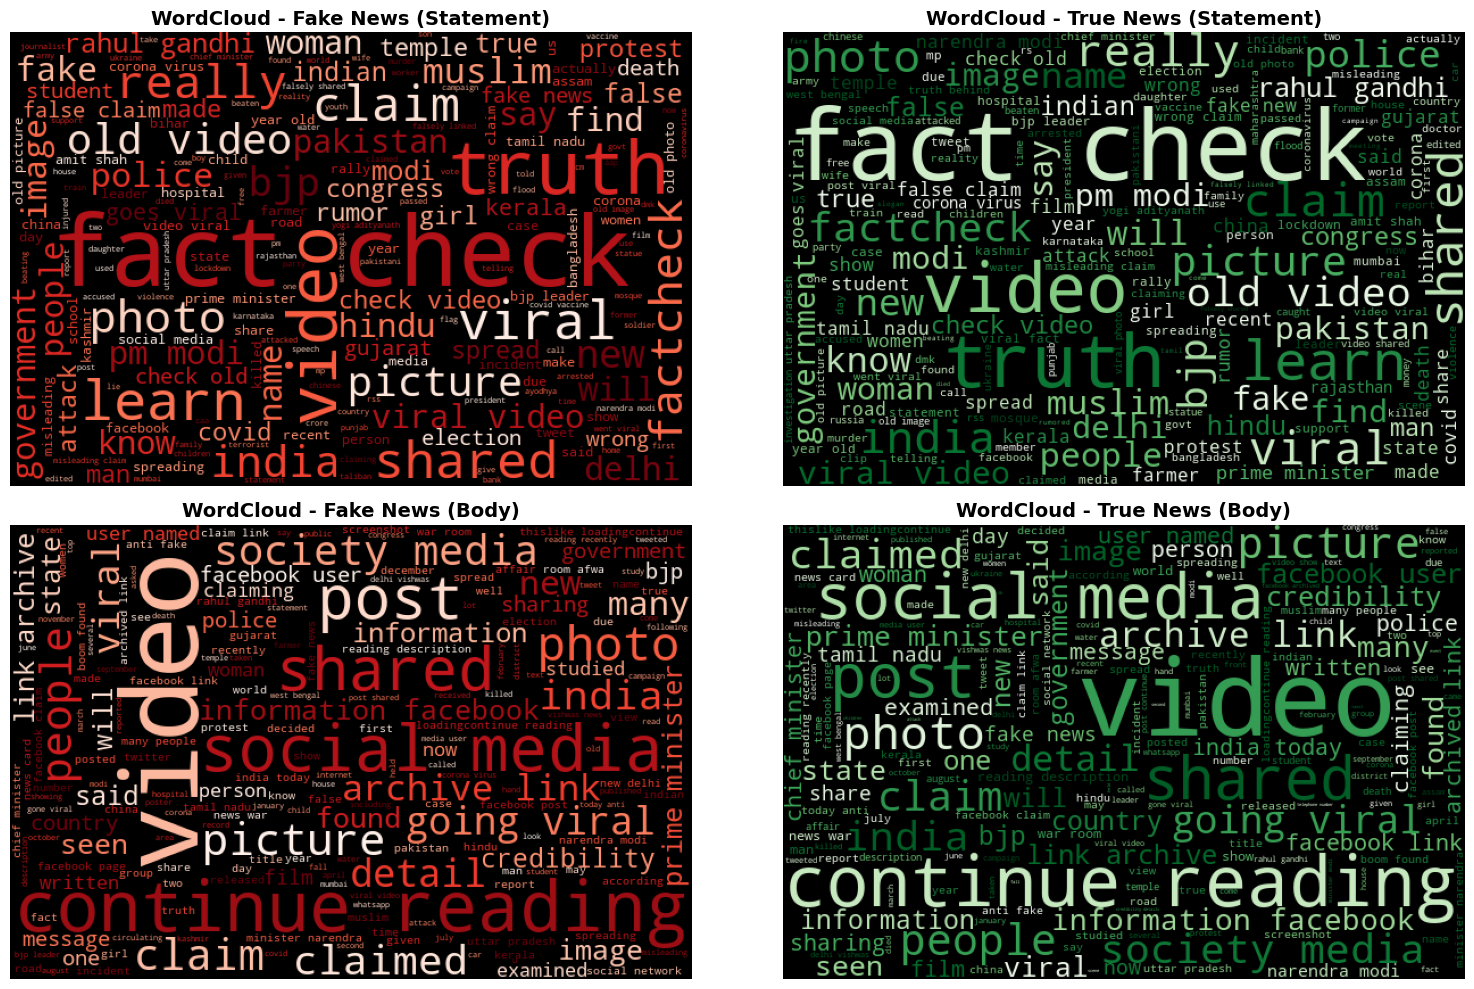

In [ ]:
# ==================== CELL 5: Enhanced Visualizations ====================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Class balance
sns.countplot(x=df['Label'], ax=axes[0, 0], palette=['#FF6B6B', '#4ECDC4'])
axes[0, 0].set_title("Class Distribution (0=Fake, 1=True)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Label")
axes[0, 0].set_ylabel("Count")

# Statement word count by label
sns.boxplot(x='Label', y='statement_word_count', data=df, ax=axes[0, 1], palette=['#FF6B6B', '#4ECDC4'])
axes[0, 1].set_title("Statement Word Count by Label", fontsize=12, fontweight='bold')

# Body word count by label
sns.boxplot(x='Label', y='body_word_count', data=df, ax=axes[0, 2], palette=['#FF6B6B', '#4ECDC4'])
axes[0, 2].set_title("Body Word Count by Label", fontsize=12, fontweight='bold')

# Statement word count distribution
sns.histplot(df['statement_word_count'], bins=50, ax=axes[1, 0], color='#45B7D1')
axes[1, 0].set_title("Statement Word Count Distribution", fontsize=12, fontweight='bold')

# Body word count distribution
sns.histplot(df['body_word_count'], bins=50, ax=axes[1, 1], color='#FFA07A')
axes[1, 1].set_title("Body Word Count Distribution", fontsize=12, fontweight='bold')

# Correlation heatmap
corr_features = df[['statement_word_count', 'body_word_count', 'statement_char_count', 
                     'body_char_count', 'avg_word_length_stmt', 'avg_word_length_body', 'Label']].corr()
sns.heatmap(corr_features, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 2], cbar_kws={'label': 'Correlation'})
axes[1, 2].set_title("Feature Correlation", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('enhanced_eda.png', dpi=300, bbox_inches='tight')
plt.show()

# WordClouds
fake_text_stmt = " ".join(df[df['Label']==0]['statement_clean'])
true_text_stmt = " ".join(df[df['Label']==1]['statement_clean'])
fake_text_body = " ".join(df[df['Label']==0]['body_clean'])
true_text_body = " ".join(df[df['Label']==1]['body_clean'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

wc_fake_stmt = WordCloud(width=600, height=400, background_color='black', colormap='Reds').generate(fake_text_stmt)
axes[0, 0].imshow(wc_fake_stmt)
axes[0, 0].set_title("WordCloud - Fake News (Statement)", fontsize=14, fontweight='bold')
axes[0, 0].axis("off")

wc_true_stmt = WordCloud(width=600, height=400, background_color='black', colormap='Greens').generate(true_text_stmt)
axes[0, 1].imshow(wc_true_stmt)
axes[0, 1].set_title("WordCloud - True News (Statement)", fontsize=14, fontweight='bold')
axes[0, 1].axis("off")

wc_fake_body = WordCloud(width=600, height=400, background_color='black', colormap='Reds').generate(fake_text_body)
axes[1, 0].imshow(wc_fake_body)
axes[1, 0].set_title("WordCloud - Fake News (Body)", fontsize=14, fontweight='bold')
axes[1, 0].axis("off")

wc_true_body = WordCloud(width=600, height=400, background_color='black', colormap='Greens').generate(true_text_body)
axes[1, 1].imshow(wc_true_body)
axes[1, 1].set_title("WordCloud - True News (Body)", fontsize=14, fontweight='bold')
axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig('wordclouds_enhanced.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# ==================== CELL 6: Advanced Feature Extraction ====================
print("\n" + "="*80)
print("CREATING MULTIPLE FEATURE SETS")
print("="*80)

# Feature Set 1: Combined TF-IDF (Statement + Body combined)
vectorizer_combined = TfidfVectorizer(
    max_features=10000,  # Increased from 5000
    ngram_range=(1, 3),   # Trigrams
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Feature Set 2: Statement TF-IDF
vectorizer_statement = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Feature Set 3: Body TF-IDF
vectorizer_body = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Feature Set 4: Character-level TF-IDF
vectorizer_char = TfidfVectorizer(
    max_features=5000,
    analyzer='char',
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95
)

print("✅ Vectorizers configured")


CREATING MULTIPLE FEATURE SETS
✅ Vectorizers configured


In [ ]:
# ==================== CELL 7: Train-Test Split with Multiple Feature Sets ====================
X = df['text_combined']
y = df['Label']

# Statistical features
stat_features = df[['statement_word_count', 'body_word_count', 'statement_char_count', 
                     'body_char_count', 'avg_word_length_stmt', 'avg_word_length_body']].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
stat_train, stat_test = train_test_split(stat_features, test_size=0.2, stratify=y, random_state=42)

# Create TF-IDF features
print("\n🔄 Creating TF-IDF features...")

# Combined text features
X_train_combined = vectorizer_combined.fit_transform(X_train)
X_test_combined = vectorizer_combined.transform(X_test)

# Statement features
X_train_stmt = vectorizer_statement.fit_transform(df.loc[X_train.index, 'text_statement'])
X_test_stmt = vectorizer_statement.transform(df.loc[X_test.index, 'text_statement'])

# Body features
X_train_body = vectorizer_body.fit_transform(df.loc[X_train.index, 'text_body'])
X_test_body = vectorizer_body.transform(df.loc[X_test.index, 'text_body'])

# Character features
X_train_char = vectorizer_char.fit_transform(X_train)
X_test_char = vectorizer_char.transform(X_test)

print("✅ TF-IDF features created")

# Concatenate all features
from scipy.sparse import hstack, csr_matrix

X_train_all = hstack([X_train_combined, X_train_stmt, X_train_body, X_train_char, csr_matrix(stat_train)])
X_test_all = hstack([X_test_combined, X_test_stmt, X_test_body, X_test_char, csr_matrix(stat_test)])

print(f"✅ All features combined: {X_train_all.shape}")

# Apply SMOTE for better class balance
print("\n🔄 Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_all, y_train)
print(f"✅ Training set balanced: {X_train_balanced.shape}")


🔄 Creating TF-IDF features...
✅ TF-IDF features created
✅ All features combined: (20288, 25006)

🔄 Applying SMOTE...
✅ Training set balanced: (24676, 25006)


In [ ]:
# ==================== CELL 8: Train Individual Models (Enhanced) ====================
print("\n" + "="*80)
print("TRAINING INDIVIDUAL MODELS")
print("="*80)

models = {
    # Linear Models (Fast)
    "Logistic Regression": LogisticRegression(max_iter=2000, C=1.0, solver='saga', n_jobs=-1),
    "Ridge Classifier": RidgeClassifier(alpha=1.0),
    "SGD Classifier": SGDClassifier(loss='hinge', penalty='l2', alpha=0.0001, max_iter=2000, n_jobs=-1),
    
    # SVM Models
    "Linear SVM": LinearSVC(C=1.0, max_iter=2000, dual=False),
    
    # Naive Bayes
    "Multinomial NB": MultinomialNB(alpha=0.1),
    "Complement NB": ComplementNB(alpha=0.1),
    
    # Tree-based Models
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=50, min_samples_split=5, n_jobs=-1, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, max_depth=50, min_samples_split=5, n_jobs=-1, random_state=42),
    # "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=7, random_state=42),
    
    # Boosting Models
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=7, learning_rate=0.1, subsample=0.8, 
                             colsample_bytree=0.8, n_jobs=-1, random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=300, max_depth=7, learning_rate=0.1, subsample=0.8,
                               colsample_bytree=0.8, n_jobs=-1, random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=300, depth=7, learning_rate=0.1, verbose=0, random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    start_time = time.time()
    
    model.fit(X_train_balanced, y_train_balanced)
    preds = model.predict(X_test_all)
    
    train_time = time.time() - start_time
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'Time (s)': train_time
    }
    
    trained_models[name] = model
    
    print(f"✅ {name}: Acc={acc:.4f}, F1={f1:.4f}, Time={train_time:.2f}s")


TRAINING INDIVIDUAL MODELS

🔄 Training Logistic Regression...
✅ Logistic Regression: Acc=0.5260, F1=0.5877, Time=234.25s

🔄 Training Ridge Classifier...
✅ Ridge Classifier: Acc=0.5509, F1=0.6206, Time=11.00s

🔄 Training SGD Classifier...
✅ SGD Classifier: Acc=0.6080, F1=0.7563, Time=9.61s

🔄 Training Linear SVM...
✅ Linear SVM: Acc=0.5534, F1=0.6241, Time=19.17s

🔄 Training Multinomial NB...
✅ Multinomial NB: Acc=0.5473, F1=0.6116, Time=0.06s

🔄 Training Complement NB...
✅ Complement NB: Acc=0.5473, F1=0.6116, Time=0.06s

🔄 Training Random Forest...
✅ Random Forest: Acc=0.6173, F1=0.7351, Time=35.02s

🔄 Training Extra Trees...
✅ Extra Trees: Acc=0.6246, F1=0.7396, Time=41.08s

🔄 Training XGBoost...
✅ XGBoost: Acc=0.6009, F1=0.7208, Time=307.31s

🔄 Training LightGBM...
✅ LightGBM: Acc=0.6011, F1=0.7208, Time=94.83s

🔄 Training CatBoost...
✅ CatBoost: Acc=0.6065, F1=0.7302, Time=424.32s


In [ ]:
# ==================== CELL 9: Advanced Ensemble Models ====================
print("\n" + "="*80)
print("TRAINING ENSEMBLE MODELS")
print("="*80)

# Ensemble 1: Voting Classifier (Soft Voting)
print("\n🔄 Training Soft Voting Ensemble...")
voting_soft = VotingClassifier(estimators=[
    ('lr', LogisticRegression(max_iter=2000, C=1.0, solver='saga', n_jobs=-1)),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=50, n_jobs=-1, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1, n_jobs=-1, random_state=42, eval_metric='logloss')),
    ('lgbm', LGBMClassifier(n_estimators=200, max_depth=7, learning_rate=0.1, n_jobs=-1, random_state=42, verbose=-1))
], voting='soft', n_jobs=-1)

voting_soft.fit(X_train_balanced, y_train_balanced)
v_soft_preds = voting_soft.predict(X_test_all)
results["Voting Soft (LR+RF+XGB+LGBM)"] = {
    'Accuracy': accuracy_score(y_test, v_soft_preds),
    'Precision': precision_score(y_test, v_soft_preds),
    'Recall': recall_score(y_test, v_soft_preds),
    'F1': f1_score(y_test, v_soft_preds),
    'Time (s)': 0
}
trained_models["Voting Soft (LR+RF+XGB+LGBM)"] = voting_soft

# Ensemble 2: Voting Classifier (Hard Voting)
print("🔄 Training Hard Voting Ensemble...")
voting_hard = VotingClassifier(estimators=[
    ('svm', LinearSVC(C=1.0, max_iter=2000, dual=False)),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=50, n_jobs=-1, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1, n_jobs=-1, random_state=42, eval_metric='logloss'))
], voting='hard', n_jobs=-1)

voting_hard.fit(X_train_balanced, y_train_balanced)
v_hard_preds = voting_hard.predict(X_test_all)
results["Voting Hard (SVM+RF+XGB)"] = {
    'Accuracy': accuracy_score(y_test, v_hard_preds),
    'Precision': precision_score(y_test, v_hard_preds),
    'Recall': recall_score(y_test, v_hard_preds),
    'F1': f1_score(y_test, v_hard_preds),
    'Time (s)': 0
}
trained_models["Voting Hard (SVM+RF+XGB)"] = voting_hard

# Ensemble 3: Stacking Classifier (Multi-level)
print("🔄 Training Stacking Ensemble...")
stacking = StackingClassifier(estimators=[
    ('lr', LogisticRegression(max_iter=2000, C=1.0, solver='saga', n_jobs=-1)),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=50, n_jobs=-1, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1, n_jobs=-1, random_state=42, eval_metric='logloss')),
    ('nb', MultinomialNB(alpha=0.1))
], final_estimator=LGBMClassifier(n_estimators=100, random_state=42, verbose=-1), n_jobs=-1)

stacking.fit(X_train_balanced, y_train_balanced)
s_preds = stacking.predict(X_test_all)
results["Stacking (LR+RF+XGB+NB->LGBM)"] = {
    'Accuracy': accuracy_score(y_test, s_preds),
    'Precision': precision_score(y_test, s_preds),
    'Recall': recall_score(y_test, s_preds),
    'F1': f1_score(y_test, s_preds),
    'Time (s)': 0
}
trained_models["Stacking (LR+RF+XGB+NB->LGBM)"] = stacking

# Ensemble 4: Weighted Average (Manual Ensemble)
print("🔄 Creating Weighted Average Ensemble...")
# Get probabilities from best models
xgb_proba = trained_models['XGBoost'].predict_proba(X_test_all)[:, 1]
lgbm_proba = trained_models['LightGBM'].predict_proba(X_test_all)[:, 1]
cat_proba = trained_models['CatBoost'].predict_proba(X_test_all)[:, 1]
rf_proba = trained_models['Random Forest'].predict_proba(X_test_all)[:, 1]

weighted_proba = 0.35 * xgb_proba + 0.30 * lgbm_proba + 0.20 * cat_proba + 0.15 * rf_proba
weighted_preds = (weighted_proba > 0.5).astype(int)

results["Weighted Ensemble (XGB+LGBM+CAT+RF)"] = {
    'Accuracy': accuracy_score(y_test, weighted_preds),
    'Precision': precision_score(y_test, weighted_preds),
    'Recall': recall_score(y_test, weighted_preds),
    'F1': f1_score(y_test, weighted_preds),
    'Time (s)': 0
}

print("\n✅ All ensemble models trained!")



TRAINING ENSEMBLE MODELS

🔄 Training Soft Voting Ensemble...
🔄 Training Hard Voting Ensemble...
🔄 Training Stacking Ensemble...


KeyboardInterrupt: 

In [ ]:
# ==================== CELL 10: Results Comparison ====================
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1', ascending=False)

print("\n" + "="*80)
print("📊 FINAL RESULTS COMPARISON")
print("="*80)
print(results_df.to_string())

# Save results
results_df.to_csv('ml_model_results_enhanced.csv')
print("\n✅ Results saved to 'ml_model_results_enhanced.csv'")

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Accuracy comparison
top_10 = results_df.head(10)
axes[0].barh(range(len(top_10)), top_10['Accuracy'], color=plt.cm.viridis(np.linspace(0, 1, len(top_10))))
axes[0].set_yticks(range(len(top_10)))
axes[0].set_yticklabels(top_10.index)
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Top 10 Models - Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# F1 Score comparison
axes[1].barh(range(len(top_10)), top_10['F1'], color=plt.cm.plasma(np.linspace(0, 1, len(top_10))))
axes[1].set_yticks(range(len(top_10)))
axes[1].set_yticklabels(top_10.index)
axes[1].set_xlabel('F1 Score', fontsize=12)
axes[1].set_title('Top 10 Models - F1 Score Comparison', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_comparison_enhanced.png', dpi=300, bbox_inches='tight')
plt.show()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(results_df[['Accuracy', 'Precision', 'Recall', 'F1']].head(10), 
            annot=True, cmap="YlGnBu", fmt=".4f", cbar_kws={'label': 'Score'})
plt.title("Top 10 Models - Performance Heatmap", fontsize=14, fontweight='bold')
plt.ylabel("Model", fontsize=12)
plt.xlabel("Metric", fontsize=12)
plt.tight_layout()
plt.savefig('performance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# ==================== CELL 11: Best Model Analysis ====================
best_model_name = results_df['F1'].idxmax()
best_f1 = results_df.loc[best_model_name, 'F1']
best_acc = results_df.loc[best_model_name, 'Accuracy']

print("\n" + "="*80)
print("🏆 BEST MODEL")
print("="*80)
print(f"Model: {best_model_name}")
print(f"Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"F1 Score: {best_f1:.4f}")
print("="*80)

# Get predictions from best model
if best_model_name in trained_models:
    best_model = trained_models[best_model_name]
    final_preds = best_model.predict(X_test_all)
elif best_model_name == "Weighted Ensemble (XGB+LGBM+CAT+RF)":
    final_preds = weighted_preds
else:
    final_preds = s_preds

# Detailed classification report
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, final_preds, target_names=['Fake', 'True']))

# Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdYlGn", 
            xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'],
            cbar_kws={'label': 'Count'})
plt.title(f"Confusion Matrix - {best_model_name}\nF1 Score: {best_f1:.4f}", 
          fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_best_model.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ==================== CELL 12: Save Best Models ====================
print("\n" + "="*80)
print("💾 SAVING MODELS AND VECTORIZERS")
print("="*80)

# Save best model
if best_model_name in trained_models:
    joblib.dump(trained_models[best_model_name], "best_model_enhanced.joblib")
    print(f"✅ Best model saved: {best_model_name}")

# Save all vectorizers
joblib.dump(vectorizer_combined, "tfidf_vectorizer_combined.joblib")
joblib.dump(vectorizer_statement, "tfidf_vectorizer_statement.joblib")
joblib.dump(vectorizer_body, "tfidf_vectorizer_body.joblib")
joblib.dump(vectorizer_char, "tfidf_vectorizer_char.joblib")
print("✅ All vectorizers saved")

# Save top 3 models
top_3_models = results_df.head(3).index.tolist()
for model_name in top_3_models:
    if model_name in trained_models:
        safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "").replace("+", "_")
        joblib.dump(trained_models[model_name], f"model_{safe_name}.joblib")
        print(f"✅ Saved: {model_name}")

print("\n" + "="*80)
print("✅ ALL MODELS TRAINED AND SAVED!")
print("="*80)
print(f"\nBest Model: {best_model_name}")
print(f"Best F1 Score: {best_f1:.4f}")
print(f"Best Accuracy: {best_acc:.4f}")
print("\n🎉 Training Complete!")
print("="*80)